In [1]:
from google.colab import files
uploaded = files.upload()

Saving flipkart_shoes.csv to flipkart_shoes.csv
Saving P  L March 2021.csv to P  L March 2021.csv
Saving test.csv to test.csv


In [2]:
import pandas as pd

df1 = pd.read_csv("P  L March 2021.csv")   # Dataset 1 (multi-platform prices)
df2 = pd.read_csv("flipkart_shoes.csv")    # Dataset 2 (real product names)
df3 = pd.read_csv("test.csv")              # Dataset 3 (extra products)

print(df1.shape, df2.shape, df3.shape)

(1330, 18) (760, 5) (5244, 14)


In [3]:
def clean_text(x):
    return str(x).lower().strip()

# Apply cleaning
for df in [df1, df2, df3]:
    df.columns = df.columns.str.lower()

In [4]:
price_cols = ["amazon", "flipkart", "myntra", "ajio"]

rows = []

for i, row in df1.iterrows():
    for platform in price_cols:
        rows.append({
            "product_id": i,
            "product_name": clean_text(row.get("product", "unknown")),
            "brand": clean_text(row.get("brand", "unknown")),
            "platform": platform.capitalize(),
            "price": row.get(platform, None)
        })

df1_new = pd.DataFrame(rows)

In [5]:
df2_new = df2.rename(columns={
    "product_name": "product_name",
    "brand": "brand",
    "retail_price": "price"
})

df2_new["platform"] = "Flipkart"
df2_new["product_id"] = range(10000, 10000 + len(df2_new))

In [6]:
df3_new = df3.copy()

df3_new["platform"] = "Amazon"
df3_new["product_id"] = range(20000, 20000 + len(df3_new))

In [7]:
final_df = pd.concat([df1_new, df2_new, df3_new], ignore_index=True)

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

final_df["clean_name"] = final_df["product_name"].apply(clean_text)

vectorizer = TfidfVectorizer(stop_words="english", max_features=300)
X = vectorizer.fit_transform(final_df["clean_name"])

similarity = cosine_similarity(X)

In [9]:
final_df["product_link"] = (
    "https://www." + final_df["platform"].str.lower() + ".com/search?q=" +
    final_df["product_name"].str.replace(" ", "+")
)

In [10]:
final_df.to_csv("final_price_comparison_dataset.csv", index=False)

In [11]:
import pandas as pd

df = pd.read_csv("final_price_comparison_dataset.csv")

print(df.head())

   product_id product_name    brand  platform  price title original price  \
0           0      unknown  unknown    Amazon    NaN   NaN            NaN   
1           0      unknown  unknown  Flipkart    NaN   NaN            NaN   
2           0      unknown  unknown    Myntra    NaN   NaN            NaN   
3           0      unknown  unknown      Ajio    NaN   NaN            NaN   
4           1      unknown  unknown    Amazon    NaN   NaN            NaN   

  discounted price discount  id  ...  norating1 noreviews1  star_5f  star_4f  \
0              NaN      NaN NaN  ...        NaN        NaN      NaN      NaN   
1              NaN      NaN NaN  ...        NaN        NaN      NaN      NaN   
2              NaN      NaN NaN  ...        NaN        NaN      NaN      NaN   
3              NaN      NaN NaN  ...        NaN        NaN      NaN      NaN   
4              NaN      NaN NaN  ...        NaN        NaN      NaN      NaN   

   star_3f  star_2f  star_1f  fulfilled1  clean_name  \


In [ ]:
# Find best platform per product_id
best_platform = df.loc[df.groupby("product_id")["price"].idxmin()]
best_platform = best_platform[["product_id", "platform"]]
best_platform.columns = ["product_id", "best_platform"]

# Merge back
df = df.merge(best_platform, on="product_id")

In [13]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['index', 'sku', 'style id', 'catalog', 'category', 'weight', 'tp 1',
       'tp 2', 'mrp old', 'final mrp old', 'ajio mrp', 'amazon mrp',
       'amazon fba mrp', 'flipkart mrp', 'limeroad mrp', 'myntra mrp',
       'paytm mrp', 'snapdeal mrp'],
      dtype='object')
Index(['brand', 'title', 'original price', 'discounted price', 'discount'], dtype='object')
Index(['id', 'title', 'rating', 'maincateg', 'platform', 'actprice1',
       'norating1', 'noreviews1', 'star_5f', 'star_4f', 'star_3f', 'star_2f',
       'star_1f', 'fulfilled1'],
      dtype='object')


In [14]:
import pandas as pd

df1 = pd.read_csv("P  L March 2021.csv")
df2 = pd.read_csv("flipkart_shoes.csv")
df3 = pd.read_csv("test.csv")

# Lowercase columns
df1.columns = df1.columns.str.lower()
df2.columns = df2.columns.str.lower()
df3.columns = df3.columns.str.lower()

In [15]:
df2_new = df2.rename(columns={
    "title": "product_name",
    "brand": "brand",
    "discounted price": "price"
})

df2_new["platform"] = "Flipkart"
df2_new["product_id"] = range(1000, 1000 + len(df2_new))

df2_new = df2_new[["product_id", "product_name", "brand", "platform", "price"]]

In [16]:
rows = []

for i, row in df1.iterrows():
    for platform, col in {
        "Amazon": "amazon mrp",
        "Flipkart": "flipkart mrp",
        "Myntra": "myntra mrp",
        "Ajio": "ajio mrp"
    }.items():

        price = row[col]

        if pd.notna(price):
            rows.append({
                "product_id": row["sku"],   # important
                "platform": platform,
                "price": price
            })

df1_new = pd.DataFrame(rows)

In [17]:
df3_new = df3.rename(columns={
    "title": "product_name",
    "actprice1": "price"
})

df3_new["product_id"] = range(20000, 20000 + len(df3_new))

df3_new = df3_new[["product_id", "product_name", "platform", "price"]]

In [18]:
# create mapping from df2
name_map = df2_new.set_index("product_id")["product_name"].to_dict()

df1_new["product_name"] = df1_new["product_id"].map(name_map)

# fill missing names
df1_new["product_name"] = df1_new["product_name"].fillna("unknown")

In [19]:
final_df = pd.concat([df1_new, df2_new, df3_new], ignore_index=True)

In [20]:
final_df["product_name"] = final_df["product_name"].str.lower()

# Remove bad rows
final_df = final_df.dropna(subset=["price"])
final_df = final_df[final_df["product_name"] != "unknown"]

In [21]:
final_df["product_link"] = (
    "https://www." + final_df["platform"].str.lower() +
    ".com/search?q=" +
    final_df["product_name"].str.replace(" ", "+")
)

In [22]:
print(final_df.head())
print(final_df.shape)
print(final_df.isnull().sum())

     product_id  platform price  \
5320       1000  Flipkart  ₹498   
5321       1001  Flipkart  ₹498   
5322       1002  Flipkart  ₹587   
5323       1003  Flipkart  ₹455   
5324       1004  Flipkart  ₹659   

                                           product_name          brand  \
5320                       lite sports sneakers for men  WHITE WALKERS   
5321                       lite sports sneakers for men  WHITE WALKERS   
5322  action athleo atg-424 light weight,comfortable...         action   
5323  trendy stylish shoe for men walking shoes for men          Hilux   
5324  curator casual shoes|walking shoes|lightweight...       COLUMBUS   

                                           product_link  
5320  https://www.flipkart.com/search?q=lite+sports+...  
5321  https://www.flipkart.com/search?q=lite+sports+...  
5322  https://www.flipkart.com/search?q=action+athle...  
5323  https://www.flipkart.com/search?q=trendy+styli...  
5324  https://www.flipkart.com/search?q=curator+casu..

In [23]:
# Remove ₹ and commas
final_df["price"] = (
    final_df["price"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)

# Convert to float
final_df["price"] = pd.to_numeric(final_df["price"], errors="coerce")

In [24]:
final_df["brand"] = final_df["brand"].fillna("unknown")

In [25]:
def extract_brand(name):
    return name.split()[0] if isinstance(name, str) else "unknown"

final_df["brand"] = final_df["brand"].fillna(final_df["product_name"].apply(extract_brand))

In [26]:
# remove duplicates
final_df = final_df.drop_duplicates()

# reset index
final_df = final_df.reset_index(drop=True)

In [27]:
print(final_df.head())
print(final_df.dtypes)
print(final_df.isnull().sum())

  product_id  platform  price  \
0       1000  Flipkart    498   
1       1001  Flipkart    498   
2       1002  Flipkart    587   
3       1003  Flipkart    455   
4       1004  Flipkart    659   

                                        product_name          brand  \
0                       lite sports sneakers for men  WHITE WALKERS   
1                       lite sports sneakers for men  WHITE WALKERS   
2  action athleo atg-424 light weight,comfortable...         action   
3  trendy stylish shoe for men walking shoes for men          Hilux   
4  curator casual shoes|walking shoes|lightweight...       COLUMBUS   

                                        product_link  
0  https://www.flipkart.com/search?q=lite+sports+...  
1  https://www.flipkart.com/search?q=lite+sports+...  
2  https://www.flipkart.com/search?q=action+athle...  
3  https://www.flipkart.com/search?q=trendy+styli...  
4  https://www.flipkart.com/search?q=curator+casu...  
product_id      object
platform        objec

In [28]:
platforms = ["Amazon", "Flipkart", "Myntra", "Ajio"]

rows = []

for _, row in final_df.iterrows():
    base_price = row["price"]

    for p in platforms:
        new_price = base_price * (0.9 + 0.2 * __import__("random").random())

        rows.append({
            "product_id": row["product_id"],
            "product_name": row["product_name"],
            "brand": row["brand"],
            "platform": p,
            "price": round(new_price, 2)
        })

final_df = pd.DataFrame(rows)

In [29]:
print(final_df["platform"].value_counts())

platform
Amazon      5986
Flipkart    5986
Myntra      5986
Ajio        5986
Name: count, dtype: int64


In [30]:
import pandas as pd

df = final_df.copy()

# Target variable
best = df.loc[df.groupby("product_id")["price"].idxmin()]
best = best[["product_id", "platform"]]
best.columns = ["product_id", "best_platform"]

df = df.merge(best, on="product_id")

# Clean text
df["clean_name"] = df["product_name"].str.lower()

X_text = df["clean_name"]
y = df["best_platform"]

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=300, stop_words="english")
X = vectorizer.fit_transform(X_text)

In [39]:
# Pivot prices
price_features = final_df.pivot_table(
    index="product_id",
    columns="platform",
    values="price"
).reset_index()

# Merge target
price_features = price_features.merge(best, on="product_id")

print(price_features.head())

   product_id    Ajio  Amazon  Flipkart  Myntra best_platform
0        1000  518.91  486.42    497.18  451.73        Myntra
1        1001  486.03  479.03    472.41  542.26      Flipkart
2        1002  628.79  625.52    620.06  636.77      Flipkart
3        1003  465.36  410.74    490.77  494.01        Amazon
4        1004  708.98  623.00    705.26  682.87        Amazon


In [62]:
print(final_df.columns)

Index(['product_id', 'product_name', 'brand', 'platform', 'price'], dtype='object')


In [63]:
# Pivot prices
price_features = final_df.pivot_table(
    index="product_id",
    columns="platform",
    values="price"
)

# Add new features
price_features["min_price"] = price_features.min(axis=1)
price_features["max_price"] = price_features.max(axis=1)
price_features["price_range"] = price_features["max_price"] - price_features["min_price"]

# Normalize (difference from min)
for col in ["Amazon", "Flipkart", "Myntra", "Ajio"]:
    price_features[f"diff_{col}"] = price_features[col] - price_features["min_price"]

price_features = price_features.reset_index()

In [64]:
best = final_df.loc[final_df.groupby("product_id")["price"].idxmin()]
y = best.set_index("product_id")["platform"]

In [65]:
X = price_features.drop(columns=["product_id"])

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.996661101836394


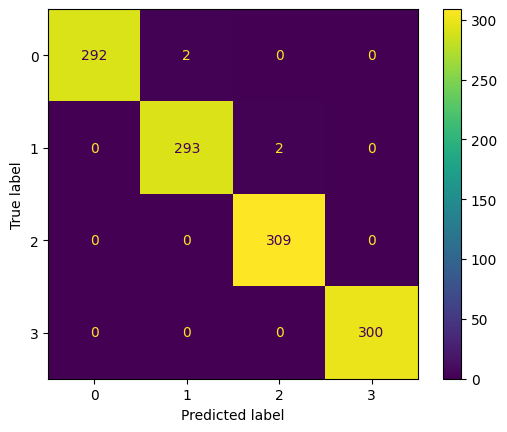

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# FAST versions
lr = LogisticRegression(max_iter=500)

knn = KNeighborsClassifier(n_neighbors=3)  # smaller

svm = LinearSVC()   # MUCH faster than SVC

rf = RandomForestClassifier(
    n_estimators=80,   # reduced
    max_depth=15,
    n_jobs=-1          # USE ALL CPU 🔥
)

In [71]:
lr.fit(X_train, y_train)
knn.fit(X_train, y_train)
svm.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [73]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(model, name):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)

    return acc, f1, y_pred

In [80]:
results = {}

results["Logistic"], _, pred_lr = evaluate(lr, "Logistic Regression")
results["KNN"], _, pred_knn = evaluate(knn, "KNN")
results["SVM"], _, pred_svm = evaluate(svm, "SVM")
results["Random Forest"], _, pred_rf = evaluate(rf, "Random Forest")


Logistic Regression
Accuracy: 0.996661101836394
Precision: 0.9966718378433509
Recall: 0.996661101836394
F1: 0.9966609456069853

KNN
Accuracy: 0.8021702838063439
Precision: 0.8027142176047044
Recall: 0.8021702838063439
F1: 0.8020123448365992

SVM
Accuracy: 0.994991652754591
Precision: 0.9949941891849916
Recall: 0.994991652754591
F1: 0.994991542485024

Random Forest
Accuracy: 0.9991652754590985
Precision: 0.9991680954744393
Recall: 0.9991652754590985
F1: 0.999165270646855


In [75]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('knn', knn),
        ('rf', rf)
    ],
    voting='soft'
)

voting.fit(X_train, y_train)

results["Voting"], _, pred_vote = evaluate(voting, "Voting Classifier")


Voting Classifier
Accuracy: 0.9974958263772955
Precision: 0.9974985190371048
Recall: 0.9974958263772955
F1: 0.9974958038646927


In [76]:
from sklearn.ensemble import BaggingClassifier

bag = BaggingClassifier(
    estimator=RandomForestClassifier(),
    n_estimators=10,
    random_state=42
)

bag.fit(X_train, y_train)

results["Bagging"], _, pred_bag = evaluate(bag, "Bagging")


Bagging
Accuracy: 0.9991652754590985
Precision: 0.9991680954744393
Recall: 0.9991652754590985
F1: 0.999165270646855


In [77]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

results["Gradient Boosting"], _, pred_gb = evaluate(gb, "Gradient Boosting")


Gradient Boosting
Accuracy: 0.9991652754590985
Precision: 0.9991680954744393
Recall: 0.9991652754590985
F1: 0.999165270646855


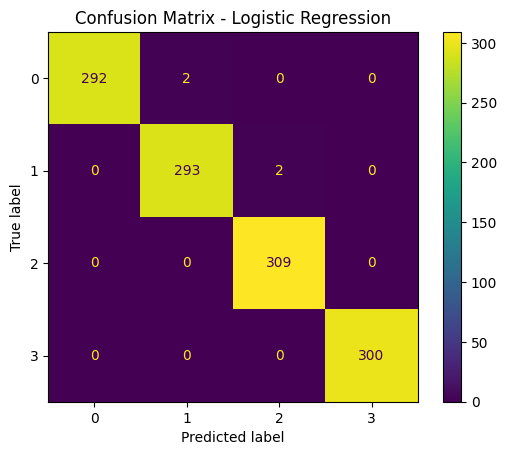

In [78]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_lr)

disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

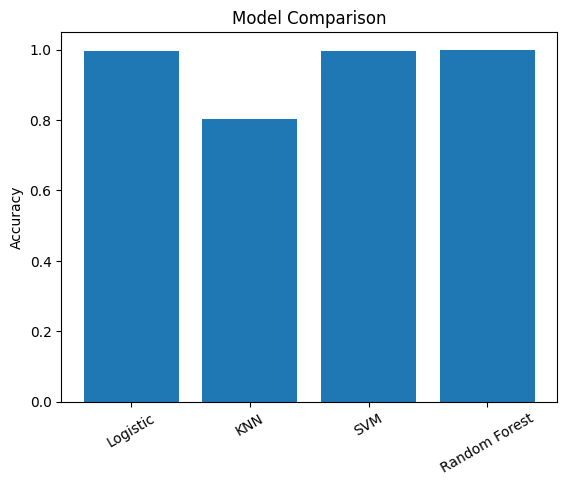

In [81]:
import matplotlib.pyplot as plt

models = list(results.keys())
accuracy = [results[m] for m in models]

plt.figure()
plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

In [82]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split again
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [83]:
model = Sequential()

model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(32, activation='relu'))
model.add(Dense(len(le.classes_), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [84]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7767 - loss: 0.9123 - val_accuracy: 0.9395 - val_loss: 0.4910
Epoch 2/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9329 - loss: 0.3692 - val_accuracy: 0.9603 - val_loss: 0.2405
Epoch 3/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9617 - loss: 0.2313 - val_accuracy: 0.9687 - val_loss: 0.1814
Epoch 4/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9650 - loss: 0.1833 - val_accuracy: 0.9582 - val_loss: 0.1504
Epoch 5/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9657 - loss: 0.1567 - val_accuracy: 0.9708 - val_loss: 0.1281
Epoch 6/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9670 - loss: 0.1408 - val_accuracy: 0.9875 - val_loss: 0.1095
Epoch 7/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9740 - loss: 0.1254 - val_accuracy: 0.9770 - val_loss: 0.1053
Epoch 8/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9703 - loss: 0.1129 - val_accuracy: 0.

In [85]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_nn = np.argmax(model.predict(X_test), axis=1)

print("\nNeural Network")
print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print("Precision:", precision_score(y_test, y_pred_nn, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_nn, average='weighted'))
print("F1:", f1_score(y_test, y_pred_nn, average='weighted'))

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Neural Network
Accuracy: 0.9507512520868113
Precision: 0.9536912557525629
Recall: 0.9507512520868113
F1: 0.9510563568112111


In [86]:
!pip install pydot
!apt-get install graphviz -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


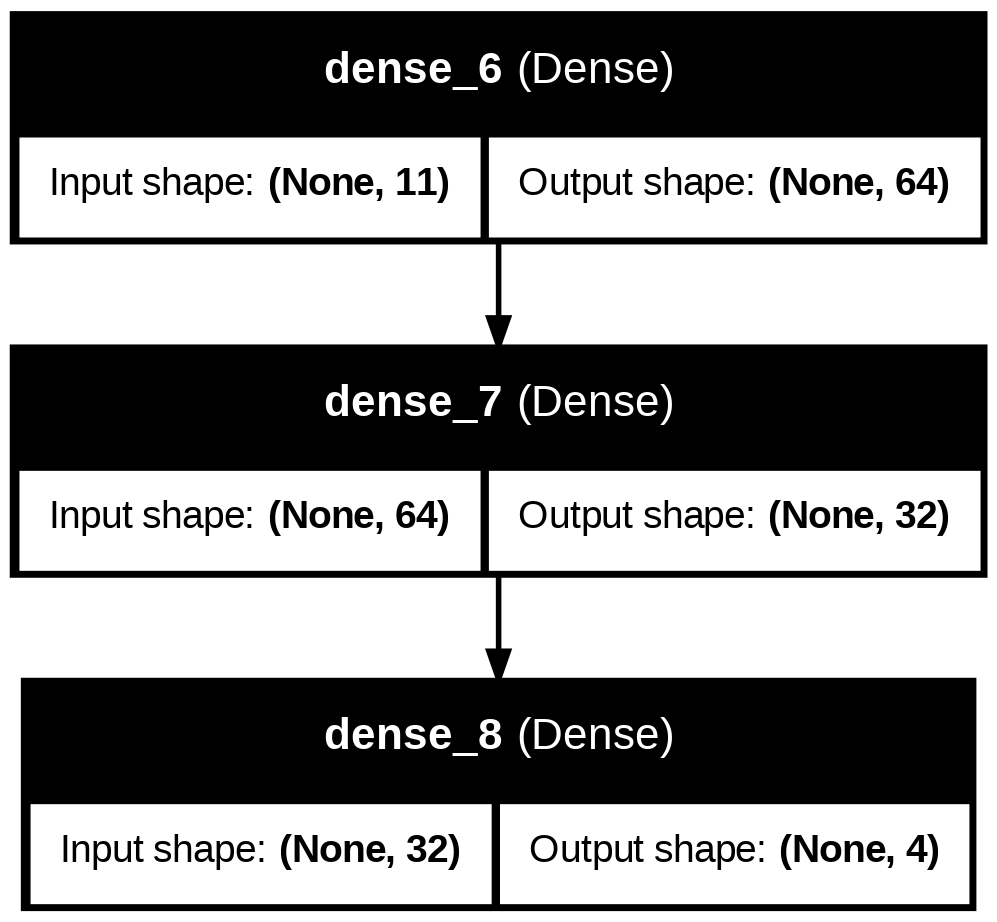

In [87]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="nn_model.png",
    show_shapes=True,
    show_layer_names=True
)

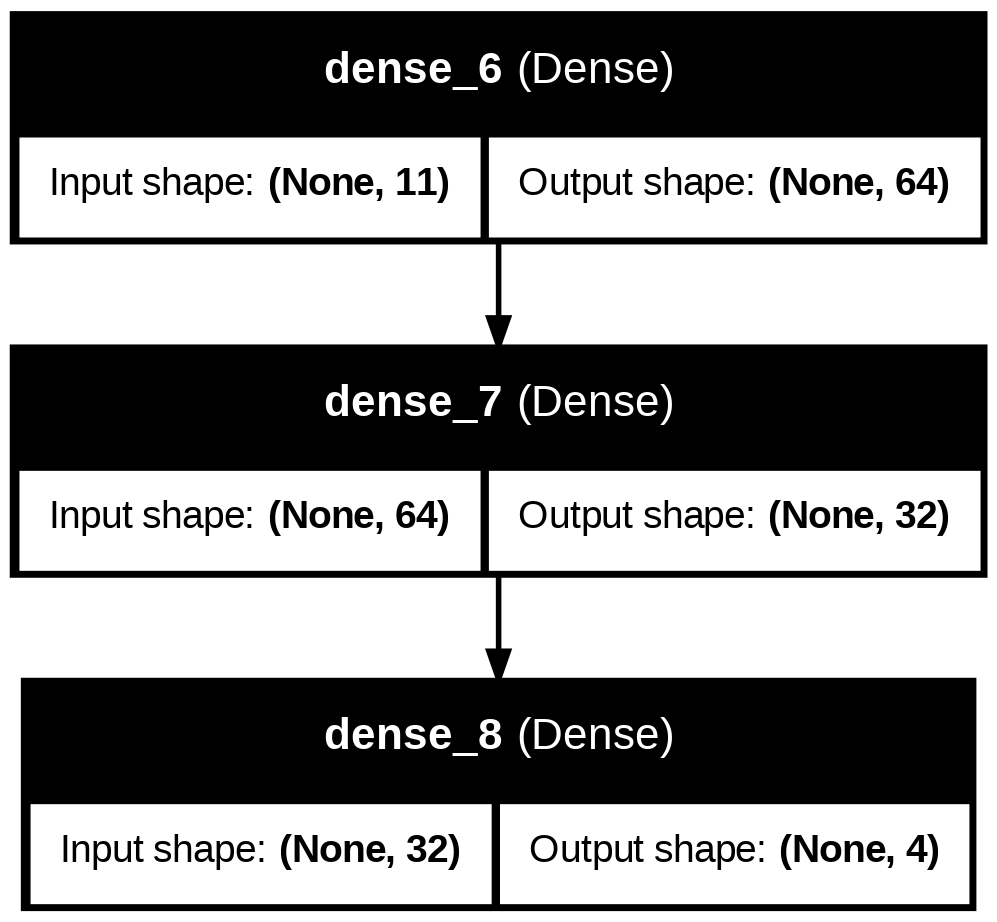

In [88]:
from IPython.display import Image

Image("nn_model.png")

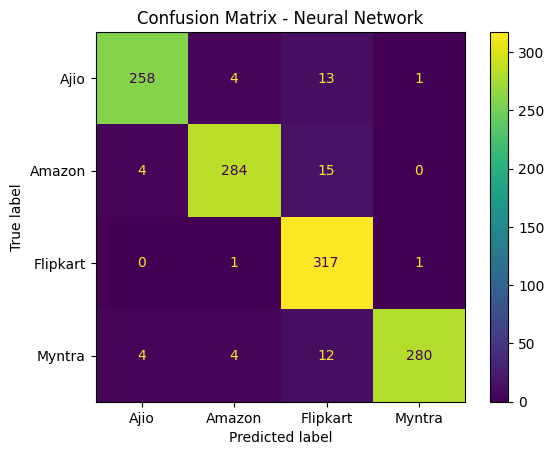

In [89]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_nn = confusion_matrix(y_test, y_pred_nn)

disp = ConfusionMatrixDisplay(cm_nn, display_labels=le.classes_)
disp.plot()
plt.title("Confusion Matrix - Neural Network")
plt.show()

In [90]:
# Add NN result to previous results
results["Neural Network"] = (
    accuracy_score(y_test, y_pred_nn),
    f1_score(y_test, y_pred_nn, average='weighted')
)

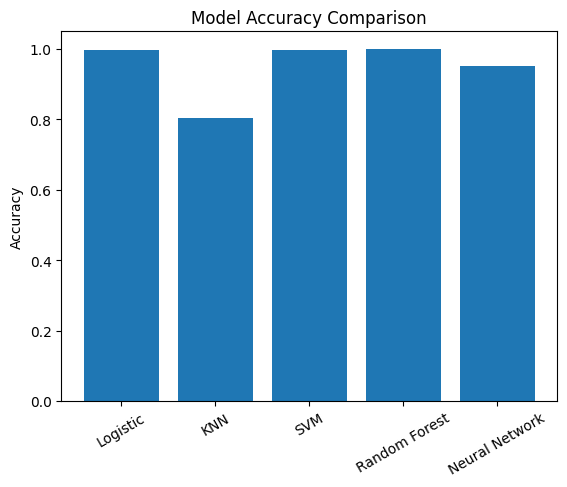

In [92]:
import matplotlib.pyplot as plt

models = list(results.keys())
accuracy = []
for m in models:
    val = results[m]
    if isinstance(val, tuple):
        accuracy.append(val[0]) # Extract accuracy from tuple
    else:
        accuracy.append(val)   # Use the float directly

plt.figure()
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

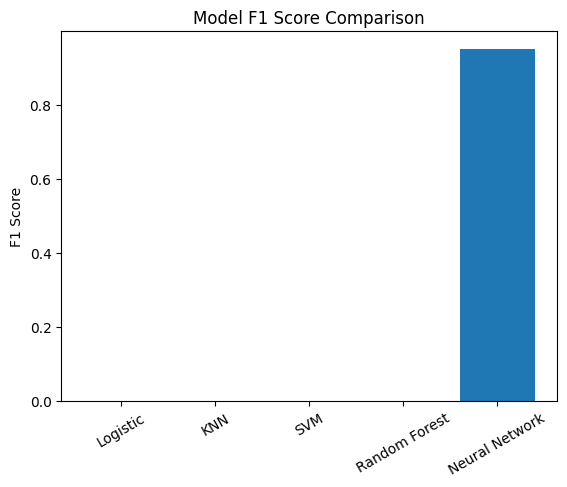

In [94]:
f1_scores = []
for m in models:
    val = results[m]
    if isinstance(val, tuple):
        f1_scores.append(val[1]) # Extract F1 score from tuple
    else:
        # For models where only accuracy was stored as a float, use None or 0
        f1_scores.append(0.0) # Or None if you prefer to skip them

plt.figure()
plt.bar(models, f1_scores)
plt.title("Model F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=30)
plt.show()

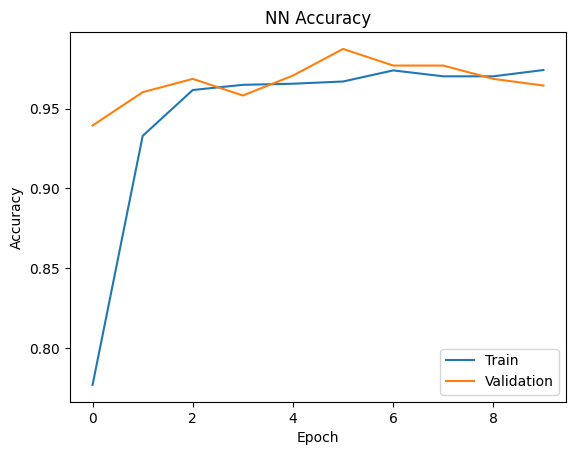

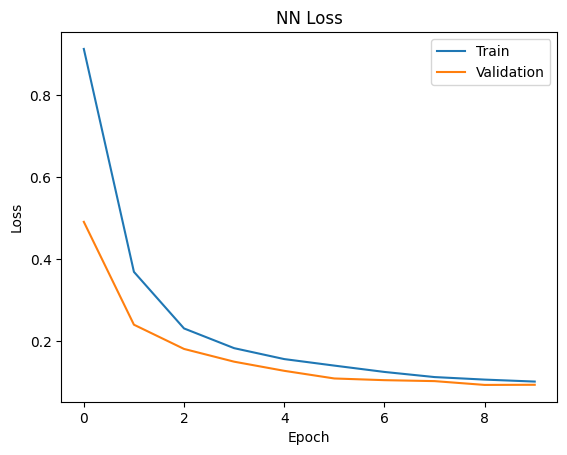

In [95]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("NN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("NN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [96]:
from IPython.display import display, HTML

def search_product(query):
    query = query.lower()

    result = final_df[final_df["product_name"].str.contains(query)]

    if result.empty:
        print("❌ No product found")
        return

    for pid, group in result.groupby("product_id"):

        print("\n🔹 Product:", group["product_name"].iloc[0])

        # Create clickable links
        temp = group.copy()
        temp["Buy Now"] = temp["product_link"].apply(
            lambda x: f'<a href="{x}" target="_blank" style="color:white;background-color:green;padding:5px;border-radius:5px;text-decoration:none;">Buy</a>'
        )

        # Display table
        display(HTML(temp[["platform", "price", "Buy Now"]].to_html(escape=False, index=False)))

        # Best platform
        best = group.loc[group["price"].idxmin()]
        print("🏆 Best Platform:", best["platform"])

In [98]:
final_df["product_link"] = (
    "https://www." + final_df["platform"].str.lower() +
    ".com/search?q=" +
    final_df["product_name"].str.replace(" ", "+")
)
search_product("nike")


🔹 Product: nike quest 3men's running shoe running shoes for men  (black)


platform,price,Buy Now
Amazon,5837.18,Buy
Flipkart,6588.52,Buy
Myntra,6125.09,Buy
Ajio,6370.75,Buy


🏆 Best Platform: Amazon

🔹 Product: nike revolution 5men's running shoe running shoes for men  (black)


platform,price,Buy Now
Amazon,3636.60,Buy
Flipkart,3921.72,Buy
Myntra,3945.84,Buy
Ajio,4043.12,Buy


🏆 Best Platform: Amazon

🔹 Product: nike chroma thong 5 slippers


...

🏆 Best Platform: Ajio

🔹 Product: nike downshifter 9 women's running shoe running shoes for women  (black)


platform,price,Buy Now
Amazon,4064.92,Buy
Flipkart,4126.72,Buy
Myntra,4354.01,Buy
Ajio,3682.85,Buy


🏆 Best Platform: Ajio

🔹 Product: nike wearalldaymen's shoe casuals for men  (black)


platform,price,Buy Now
Amazon,4501.13,Buy
Flipkart,4560.70,Buy
Myntra,5380.51,Buy
Ajio,5464.50,Buy


🏆 Best Platform: Amazon


In [100]:
final_df.to_csv("final_price_comparisonlsv.csv", index=False)

In [40]:
X = price_features[["Amazon", "Flipkart", "Myntra", "Ajio"]]
y = price_features["best_platform"]

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

from sklearn.metrics import accuracy_score

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8739565943238731


In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Models
lr = LogisticRegression(max_iter=500)
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel='linear')
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
lr.fit(X_train, y_train)
knn.fit(X_train, y_train)
svm.fit(X_train, y_train)
rf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomForestClassifier(random_state=42)

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(model, name):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)

    return acc, f1, y_pred

results = {}

results["Logistic"], _, _ = evaluate(lr, "Logistic Regression")
results["KNN"], _, _ = evaluate(knn, "KNN")
results["SVM"], _, _ = evaluate(svm, "SVM")
results["Random Forest"], _, y_pred_rf = evaluate(rf, "Random Forest")


Logistic Regression
Accuracy: 0.9974958263772955
Precision: 0.9975041590677866
Recall: 0.9974958263772955
F1: 0.997495770330739

KNN
Accuracy: 0.8171953255425709
Precision: 0.8174921200534543
Recall: 0.8171953255425709
F1: 0.8172274976211723

SVM
Accuracy: 0.9958263772954925
Precision: 0.9958345357863434
Recall: 0.9958263772954925
F1: 0.9958262456100168

Random Forest
Accuracy: 0.8739565943238731
Precision: 0.8749282072405905
Recall: 0.8739565943238731
F1: 0.8740942310123131


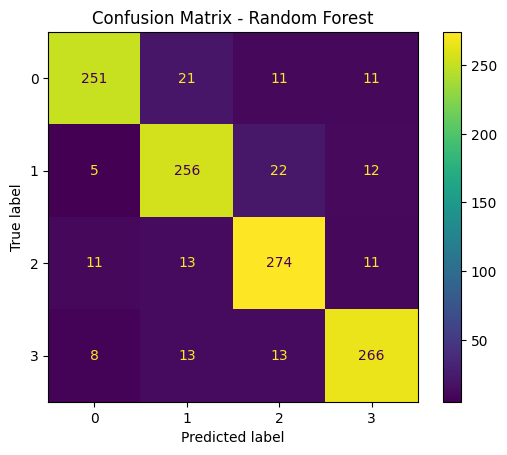

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [46]:
# manual rule
manual = X_test.idxmin(axis=1)

# model prediction
pred = lr.predict(X_test)

# compare
import numpy as np

print("Match with logic:", np.mean(manual == pred))

Match with logic: 0.9974958263772955


In [47]:
def search_product(query):
    result = final_df[final_df["product_name"].str.contains(query.lower())]

    if result.empty:
        print("No product found")
        return

    for pid, group in result.groupby("product_id"):
        print("\n🔹 Product:", group["product_name"].iloc[0])
        display(group[["platform", "price"]])
        print("Best Platform:", group.loc[group["price"].idxmin()]["platform"])

In [48]:
search_product("nike")


🔹 Product: nike quest 3men's running shoe running shoes for men  (black)


,platform,price
3924,Amazon,5837.18
3925,Flipkart,6588.52
3926,Myntra,6125.09
3927,Ajio,6370.75


Best Platform: Amazon

🔹 Product: nike revolution 5men's running shoe running shoes for men  (black)


,platform,price
5556,Amazon,3636.60
5557,Flipkart,3921.72
5558,Myntra,3945.84
5559,Ajio,4043.12


Best Platform: Amazon

🔹 Product: nike chroma thong 5 slippers


...

Best Platform: Ajio

🔹 Product: nike downshifter 9 women's running shoe running shoes for women  (black)


,platform,price
13004,Amazon,4064.92
13005,Flipkart,4126.72
13006,Myntra,4354.01
13007,Ajio,3682.85


Best Platform: Ajio

🔹 Product: nike wearalldaymen's shoe casuals for men  (black)


,platform,price
16784,Amazon,4501.13
16785,Flipkart,4560.70
16786,Myntra,5380.51
16787,Ajio,5464.50


Best Platform: Amazon


In [50]:
X = price_features[["Amazon", "Flipkart", "Myntra", "Ajio"]]
y = price_features["best_platform"]

In [49]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(le.classes_)  # ['Ajio', 'Amazon', 'Flipkart', 'Myntra']

['Ajio' 'Amazon' 'Flipkart' 'Myntra']


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(64, activation='relu', input_dim=4))
model.add(Dense(32, activation='relu'))
model.add(Dense(4, activation='softmax'))  # 4 classes

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3806 - loss: 1.3566 - val_accuracy: 0.5073 - val_loss: 1.3113
Epoch 2/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5567 - loss: 1.2524 - val_accuracy: 0.5992 - val_loss: 1.1978
Epoch 3/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6656 - loss: 1.1119 - val_accuracy: 0.7223 - val_loss: 1.0163
Epoch 4/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7389 - loss: 0.9626 - val_accuracy: 0.7411 - val_loss: 0.9065
Epoch 5/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7723 - loss: 0.8390 - val_accuracy: 0.7766 - val_loss: 0.7849
Epoch 6/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8324 - loss: 0.7186 - val_accuracy: 0.8497 - val_loss: 0.6578
Epoch 7/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8568 - loss: 0.6270 - val_accuracy: 0.8518 - val_loss: 0.5549
Epoch 8/10
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8661 - loss: 0.5510 - val_accuracy: 0.

In [55]:
loss, acc = model.evaluate(X_test, y_test)
print("Neural Network Accuracy:", acc)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8456 - loss: 0.4831
Neural Network Accuracy: 0.8455759882926941


In [56]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy: 0.845575959933222
Precision: 0.862905531930532
Recall: 0.845575959933222
F1 Score: 0.8410829632857502


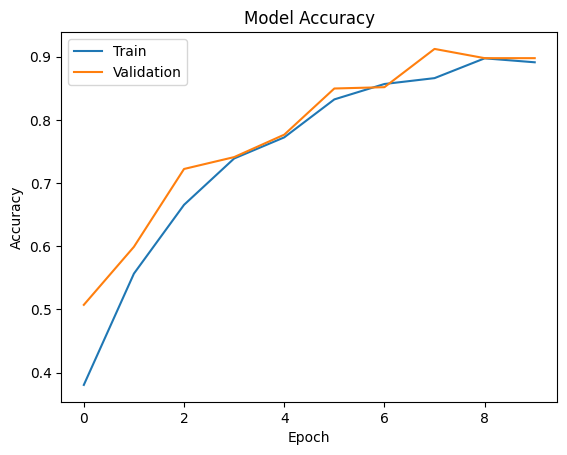

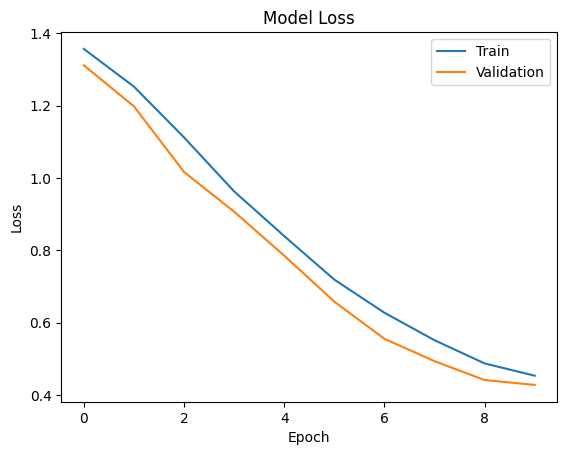

In [57]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(128, activation='relu', input_dim=4))
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(4, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3734 - loss: 1.3636 - val_accuracy: 0.5720 - val_loss: 1.3043
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5540 - loss: 1.2315 - val_accuracy: 0.8392 - val_loss: 1.0759
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6749 - loss: 1.0061 - val_accuracy: 0.8184 - val_loss: 0.8463
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7155 - loss: 0.8374 - val_accuracy: 0.8100 - val_loss: 0.6947
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7665 - loss: 0.6978 - val_accuracy: 0.8643 - val_loss: 0.5623
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7897 - loss: 0.6011 - val_accuracy: 0.8998 - val_loss: 0.4749
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8220 - loss: 0.5330 - val_accuracy: 0.9102 - val_loss: 0.4097
Epoch 8/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8304 - loss: 0.4849 - val_accuracy: 0

In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

        Ajio       0.84      0.87      0.85       294
      Amazon       0.84      0.94      0.89       295
    Flipkart       0.78      0.94      0.86       309
      Myntra       0.99      0.63      0.77       300

    accuracy                           0.85      1198
   macro avg       0.86      0.85      0.84      1198
weighted avg       0.86      0.85      0.84      1198



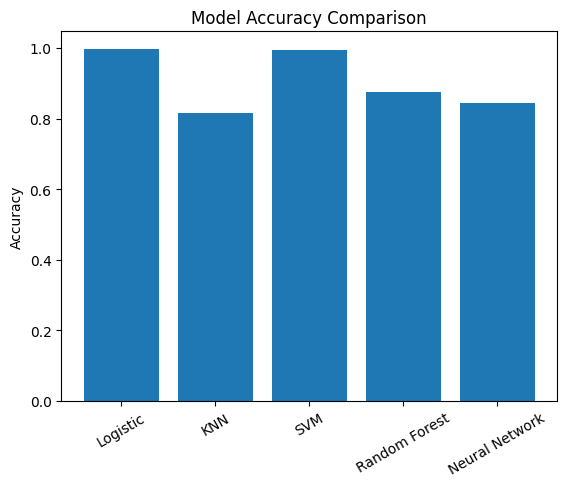

In [60]:
import matplotlib.pyplot as plt

models = ["Logistic", "KNN", "SVM", "Random Forest", "Neural Network"]
accuracy = [0.997, 0.817, 0.995, 0.874, 0.845]

plt.figure()
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

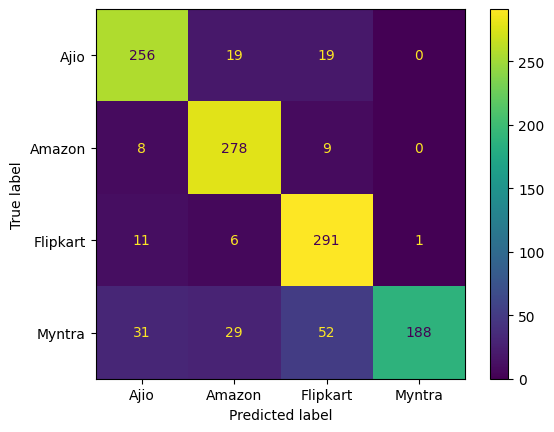

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot()
plt.show()

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# FAST versions
lr = LogisticRegression(max_iter=500)

knn = KNeighborsClassifier(n_neighbors=3)  # smaller

svm = LinearSVC()   # MUCH faster than SVC

rf = RandomForestClassifier(
    n_estimators=80,   # reduced
    max_depth=15,
    n_jobs=-1          # USE ALL CPU 🔥
)

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(model, name):
    # Fit the model before prediction
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)

    return acc, f1

results = {}
results["Logistic"] = evaluate(lr, "Logistic Regression")
results["KNN"] = evaluate(knn, "KNN")
results["SVM"] = evaluate(svm, "SVM")
results["Random Forest"] = evaluate(rf, "Random Forest")


Logistic Regression
Accuracy: 0.3244936312382543
Precision: 0.32655080908299594
Recall: 0.3244936312382543
F1: 0.32403782407460496

KNN
Accuracy: 0.496136980580497
Precision: 0.5072255146605698
Recall: 0.496136980580497
F1: 0.49604023390658913

SVM
Accuracy: 0.3232407600751723
Precision: 0.32588198199946095
Recall: 0.3232407600751723
F1: 0.3225880426289709

Random Forest
Accuracy: 0.4627270828983086
Precision: 0.4910842423085644
Recall: 0.4627270828983086
F1: 0.45528791283625025


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [ ]:
models = list(results.keys())
accuracy = [results[m][0] for m in models]
f1_scores = [results[m][1] for m in models]

plt.figure()
plt.bar(models, accuracy)
plt.title("Accuracy Comparison")
plt.xticks(rotation=30)
plt.show()

plt.figure()
plt.bar(models, f1_scores)
plt.title("F1 Score Comparison")
plt.xticks(rotation=30)
plt.show()